# Case 600 — remaining VDI parameter sensitivity

This notebook audits no-IW at 0.414 ACH with controlled Modelica solar and a 100% convective baseline for heating HVAC, cooling HVAC, and internal sensible gain. No 0.5 ACH simulation is included.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

HERE = Path.cwd().resolve()
if HERE.name != '2_vdi':
    HERE = HERE / '2_validation/_BESTEST/2_vdi'
sys.path.insert(0, str(HERE))
import case600_vdi_analysis as analysis
pd.set_option('display.max_columns', 30)
plt.style.use('seaborn-v0_8-whitegrid')

## Baseline and source trace

The RClib HVAC fractions enter `derive_hvac_fractions`, then `allocate_hvac_load`; convective load is injected in the air balance and radiant load at AW/IW receiving nodes. Because the fixed-temperature equation contains these fractions, they affect thermostat load determination as well as post-solution distribution. Modelica Case 600 instead connects its single `PrescribedHeatFlow` directly to `zonHVAC.heaPorAir`, controlled from `TAir`: its ideal HVAC is purely convective.

In [2]:
split, surface, allocation, initialization, summary = analysis.run_sensitivities()
base=analysis.metrics('baseline',analysis.simulate(),'Modelica aggregate controlled forcing',analysis.solar_series().sum()/1e6)
pd.Series(base).to_frame('value')

,value
case,baseline
heating_MWh,5.57279
cooling_MWh,4.720118
total_HVAC_MWh,10.292908
heating_EUI_kWh_m2yr,116.099789
cooling_EUI_kWh_m2yr,98.335794
total_EUI_kWh_m2yr,214.435583
peak_heating_kW,3.621739
peak_cooling_kW,4.747012
heating_hours,4185


## HVAC convective/radiant split

,sensitivity,convective_fraction,radiant_fraction,heating_EUI_kWh_m2yr,cooling_EUI_kWh_m2yr,peak_heating_kW,peak_cooling_kW,heating_hours,cooling_hours,zero_fraction_treatment
0,heating,1.0,0.0,116.100,98.336,3.622,4.747,4185,2708,exact
1,heating,0.8,0.2,124.455,99.072,3.887,4.758,4153,2726,exact
2,heating,0.6,0.4,134.067,99.888,4.190,4.769,4104,2753,exact
3,heating,0.4,0.6,145.167,100.752,4.537,4.779,4045,2770,exact
4,heating,0.2,0.8,158.072,101.631,4.944,4.789,3974,2791,exact
5,heating,0.0,1.0,172.920,102.359,5.683,4.797,3882,2805,1e-9 numerical diagnostic: exact zero rejected...
6,cooling,1.0,0.0,116.100,98.336,3.622,4.747,4185,2708,exact
7,cooling,0.8,0.2,116.821,105.918,3.622,5.229,4218,2632,exact
8,cooling,0.6,0.4,117.614,114.660,3.622,5.791,4263,2552,exact
9,cooling,0.4,0.6,118.465,124.787,3.622,6.429,4290,2471,exact


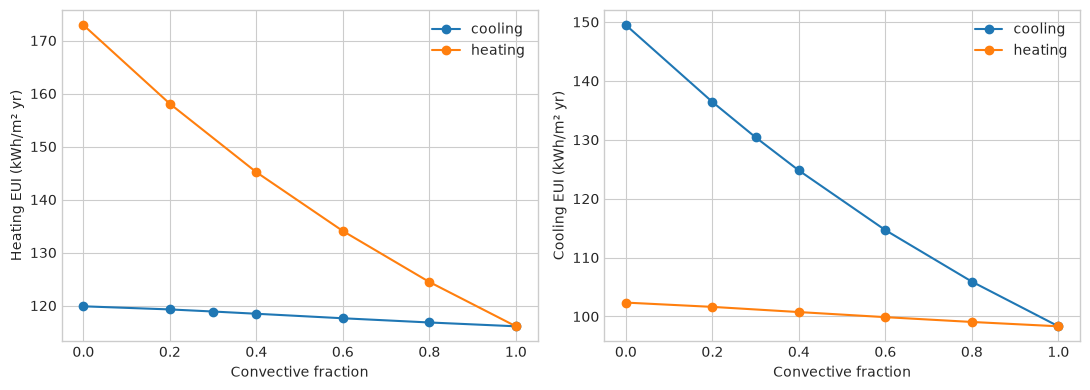

In [3]:
display(split[['sensitivity','convective_fraction','radiant_fraction','heating_EUI_kWh_m2yr','cooling_EUI_kWh_m2yr','peak_heating_kW','peak_cooling_kW','heating_hours','cooling_hours','zero_fraction_treatment']].round(3)); fig,axes=plt.subplots(1,2,figsize=(11,4));
for name,g in split.groupby('sensitivity'): axes[0].plot(g.convective_fraction,g.heating_EUI_kWh_m2yr,'o-',label=name); axes[1].plot(g.convective_fraction,g.cooling_EUI_kWh_m2yr,'o-',label=name)
axes[0].set_ylabel('Heating EUI (kWh/m² yr)'); axes[1].set_ylabel('Cooling EUI (kWh/m² yr)'); [a.set_xlabel('Convective fraction') for a in axes]; axes[0].legend(); axes[1].legend(); plt.tight_layout(); plt.show()

Exact zero was attempted first. The allocation arithmetic produces `-1.11e-16` and the fraction validator rejects it; the 0% rows therefore use `1e-9` and are explicitly labelled numerical diagnostics. This is an implementation endpoint defect, not evidence that VDI mathematically requires a nonzero fraction.

## Inside heat-transfer coefficient

In [4]:
display(surface.round(3))

,case,heating_MWh,cooling_MWh,total_HVAC_MWh,heating_EUI_kWh_m2yr,cooling_EUI_kWh_m2yr,total_EUI_kWh_m2yr,peak_heating_kW,peak_cooling_kW,heating_hours,cooling_hours,annual_solar_MWh,solar_source,heating_pass,cooling_pass,combined_pass,maximum_balance_residual_W,inside_total_coefficient_W_m2K,evidence,interpretation
0,7.7,5.502,4.447,9.949,114.628,92.636,207.264,3.560,4.469,4222,2704,12.112,Modelica aggregate controlled forcing,False,False,False,0.0,7.7,ISO 6946 Rsi=0.13 conventional total,combined coefficient; RClib subtracts fixed 5 ...
1,8.0,5.573,4.720,10.293,116.100,98.336,214.436,3.622,4.747,4185,2708,12.112,Modelica aggregate controlled forcing,False,False,False,0.0,8.0,current VDI closure,combined coefficient; RClib subtracts fixed 5 ...
2,9.1,5.778,5.452,11.230,120.366,113.584,233.950,3.785,5.508,4100,2704,12.112,Modelica aggregate controlled forcing,False,True,False,0.0,9.1,Modelica Zone5R1C hSur comparator,combined coefficient; RClib subtracts fixed 5 ...


## Radiative allocation and topology

In [5]:
display(allocation.round(4))

,topology,AW_area_m2,IW_area_m2,total_receiving_area_m2,AW_weight,IW_weight,injection
0,96 m2 IW,171.6,96.0,267.6,0.6413,0.3587,internal_radiant_gain_w
1,no-IW,171.6,0.0,171.6,1.0000,0.0000,internal_radiant_gain_w


The controlled scalar source is injected into `internal_radiant_gain_w`. The standard topology distributes it by receiving area between AW and the 96 m² IW branch; no-IW sends 100% to AW. Thus removing IW changes both storage topology and the solar/internal-radiant receiving weights. This is not equivalent to Modelica's `phiSur`/`phiMas` receiving-surface calculation and is a high-priority closure issue.

## Initialization / warm-up

In [6]:
display(initialization.round(5)); delta=initialization.set_index('initialization').diff().iloc[-1]; display(delta.to_frame('warm minus cold'))

,initialization,annual_heating_MWh,annual_cooling_MWh,first_week_heating_MWh,first_week_cooling_MWh,first_month_heating_MWh,first_month_cooling_MWh
0,20C zero-history,5.57279,4.72012,0.23081,0.05392,0.87788,0.35379
1,one repeated-year warm-up,5.57750,4.72011,0.23551,0.05392,0.88259,0.35379


,warm minus cold
annual_heating_MWh,0.004709
annual_cooling_MWh,-0.000006
first_week_heating_MWh,0.004709
first_week_cooling_MWh,-0.000006
first_month_heating_MWh,0.004709
first_month_cooling_MWh,-0.000006


## Envelope, floor, long-wave, gains, and airflow audit

In [7]:
display(pd.read_csv(analysis.OUTS/'case600_vdi_floor_boundary_audit.csv')); print(f"0.414 ACH flow = {0.414*129.6/3600:.5f} m³/s; RClib ventilation conductance = {1.20*1005*0.414*129.6/3600:.3f} W/K")

,construction,boundary_condition,surface_films,thermal_storage,candidate_VDI_classification,BESTEST_Modelica_treatment,status
0,1.003 m massless insulation proxy + 25 mm timber,Outdoors in current VDI input,Rsi implicit in U target; Rse=0.04 used by ada...,timber only; insulation rho*cp=1e-18,"AW, but boundary must represent BESTEST adiaba...","UFlo=0.038, AFlo=48, b=1 to outdoor node",model-form/boundary representation requires ca...


0.414 ACH flow = 0.01490 m³/s; RClib ventilation conductance = 17.974 W/K


Layer-only resistance and film check:

| Assembly | Layer-only R (m²K/W) | Rsi used in target check | Rse | Total R | Derived U | Target U |
|---|---:|---:|---:|---:|---:|---:|
| Wall | 1.789 | 0.0577 | 0.040 | 1.887 | 0.530 | 0.530 |
| Roof | 2.997 | -0.0069* | 0.040 | 3.030 | 0.330 | 0.330 |
| Floor | 25.253 | 1.023 | 0.040 | 26.316 | 0.038 | 0.038 |

`*` The roof layer sum is already slightly more resistive than the prescribed total U-value, demonstrating that layers and prescribed U cannot simultaneously define films exactly. RClib uses prescribed U for whole-assembly boundary conductance but also passes Rse into the reduced-network residual. That mixed convention is unresolved and can double-count/misallocate film resistance in dynamics even though steady boundary weighting uses U.

The floor remains an AW with an outdoor-equivalent boundary in the VDI input, matching the local Modelica parameters `AFlo=48`, `UFlo=.038`, `b=1` at the aggregate ISO level. Its 1.003 m insulation proxy is effectively massless and timber stores heat. BESTEST's very low-U floor is not a license to make it adiabatic.

Internal sensible gain is prescribed as 200 W and is assigned 100% to air in this requested comparison. The local Modelica ISO model instead sends 50% to air (`phiAir(k=0.5)`) and distributes the remainder to surface/mass, so this is recorded as a closure assumption rather than claimed equivalence. Exterior long-wave remains explicit in VDI.

## Suspicious-parameter ranking

In [8]:
display(summary)

,parameter,baseline value,source,BESTEST prescribed?,VDI required?,Modelica comparator treatment,sensitivity magnitude,direction of heating change,direction of cooling change,physical plausibility,priority,status
0,HVAC convective/radiant split,H 100/0; C 100/0,requested comparison baseline,False,True,pure convective heaPorAir,see split CSV,case-dependent,case-dependent,high,high,cross-model closure assumption
1,solar/radiative redistribution,AW/IW area allocation,RClib sources.py,False,True,ISO surface/mass allocation,topology-material,unresolved,unresolved,medium,high,likely implementation issue
2,inside surface coefficient,8 W/m2K,VDIAdapterDefaults,False,True,hSur=9.1 W/m2K,see coefficient CSV,see CSV,see CSV,medium,medium,cross-model closure assumption
3,exterior films/U consistency,Rse=0.04; U prescribed,defaults JSON,True,True,U parameters directly used,audit only,possible increase if duplicated,possible decrease,high,high,UNRESOLVED
4,floor boundary,"AW outdoors, U=0.038",defaults JSON,True,True,"AFlo=48, UFlo=.038, b=1",audit only,unresolved,unresolved,medium,high,model-form difference
5,long-wave exterior,"EPW HIR, eps .90/.93",RClib boundary,False,True,ISO13790 exterior equivalent boundary omits ex...,not isolated,possible increase,possible decrease,medium,medium,model-form difference
6,initialization,20C zero history,RClib state,False,True,Modelica initial equations,see initialization CSV,see CSV,see CSV,high,low,low-impact assumption
7,ventilation air properties,"rho=1.20, cp=1005; 0.414 ACH",VDIAdapterDefaults,False,True,airRat=.414 in Zone5R1C,G=17.974 W/K,higher ACH raises,higher ACH lowers,high,medium,cross-model closure assumption
8,internal sensible split,100/0 convective/radiant,requested comparison baseline,True,True,Zone5R1C phiAir k=.5 then surface/mass split,not swept,n/a,n/a,medium,high,cross-model closure assumption


## Conclusion

The strongest demonstrated sensitivity is the HVAC delivery split, and the strongest topology-coupled concern is radiant redistribution when the 96 m² IW receiver disappears. Initialization is classified from the measured annual deltas, not intuition. Inside coefficient sensitivity is bounded by documented comparator/conventional values. Surface-film consistency, floor representation, and exterior long-wave remain evidence-led audits rather than tuned switches. See `case600_vdi_remaining_parameter_findings.md` and the CSVs in `results/case600_vdi_remaining_sensitivity/`.